In [ ]:
import os
import cv2
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Device:", device)


✅ Device: cpu


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!ls "/content/drive/MyDrive"



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 archive.zip	    Infosys_25_Day_DSE_Plan_FULL.docx
'Colab Notebooks'   morph_detection
 content	    morph_project
 datasets	   'Sunderkand & Hanuman Chalisa.pdf'


In [ ]:
!mkdir -p /content/morph_project


In [ ]:
!unzip "/content/drive/MyDrive/morph_project/datasets/archive (1).zip" -d "/content/morph_project/"


Streaming output truncated to the last 5000 lines.
  inflating: /content/morph_project/CASIA2/Tp/Tp_D_CRN_M_N_arc00045_arc00046_10084.tif  
  inflating: /content/morph_project/CASIA2/Tp/Tp_D_CRN_M_N_arc00045_arc00071_10087.tif  
  inflating: /content/morph_project/CASIA2/Tp/Tp_D_CRN_M_N_arc00046_arc00045_10083.tif  
  inflating: /content/morph_project/CASIA2/Tp/Tp_D_CRN_M_N_arc00054_cha00085_11922.jpg  
  inflating: /content/morph_project/CASIA2/Tp/Tp_D_CRN_M_N_arc00071_arc00045_10085.tif  
  inflating: /content/morph_project/CASIA2/Tp/Tp_D_CRN_M_N_arc00073_arc00072_10267.tif  
  inflating: /content/morph_project/CASIA2/Tp/Tp_D_CRN_M_N_arc00088_arc00064_10394.tif  
  inflating: /content/morph_project/CASIA2/Tp/Tp_D_CRN_M_N_art00012_art00013_11812.jpg  
  inflating: /content/morph_project/CASIA2/Tp/Tp_D_CRN_M_N_art00014_art00013_11836.jpg  
  inflating: /content/morph_project/CASIA2/Tp/Tp_D_CRN_M_N_art00058_art00049_10529.tif  
  inflating: /content/morph_project/CASIA2/Tp/Tp_D_CRN_M_N_

In [ ]:
import os

csv_dir = "/content/morph_project/data/csv"
os.makedirs(csv_dir, exist_ok=True)
csv_dir


'/content/morph_project/data/csv'

In [ ]:
import pandas as pd
from pathlib import Path

images_root = "/content/morph_project"

image_paths = list(Path(images_root).rglob("*.*"))
print("Total found:", len(image_paths))

data = []
for p in image_paths:
    name = p.name.lower()
    if name.endswith((".jpg", ".jpeg", ".png", ".tif")):
        # label rule: 'Tp' means tampered (attack), 'Au' means authentic (bonafide)
        if "tp_" in name or name.startswith("tp"):
            label = "attack"
        else:
            label = "bonafide"
        data.append([str(p), label])

print("Usable images:", len(data))
df = pd.DataFrame(data, columns=["image", "label"])
df.head()


Total found: 0
Usable images: 0


,image,label


In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,            # 30% goes to temp → split into val/test
    shuffle=True,
    random_state=42,
    stratify=df["label"]       # keeps label ratio balanced
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,            # half of 30% = 15% each
    shuffle=True,
    random_state=42,
    stratify=temp_df["label"]
)

print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))


Train size: 12378
Val size: 2652
Test size: 2653


In [ ]:
import os

os.makedirs("/content/morph_project/data/csv", exist_ok=True)

train_df.to_csv("/content/morph_project/data/csv/train.csv", index=False)
val_df.to_csv("/content/morph_project/data/csv/val.csv", index=False)
test_df.to_csv("/content/morph_project/data/csv/test.csv", index=False)


In [ ]:
print("Train CSV:", os.path.exists("/content/morph_project/data/csv/train.csv"))
print("Val CSV:", os.path.exists("/content/morph_project/data/csv/val.csv"))
print("Test CSV:", os.path.exists("/content/morph_project/data/csv/test.csv"))


Train CSV: True
Val CSV: True
Test CSV: True


In [ ]:
import cv2
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

class CASIADataset(Dataset):
    def __init__(self, csv_path, transform=None):
        self.df = pd.read_csv(csv_path)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        img_path = self.df.iloc[index, 0]
        label = self.df.iloc[index, 1]

        # Read image (BGR in cv2)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            img = self.transform(image=img)["image"]

        return img, torch.tensor(1 if label == "attack" else 0, dtype=torch.long)

# ✅ Albumentations transforms
train_tf = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_tf = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])



In [ ]:
train_loader = DataLoader(
    CASIADataset("/content/morph_project/data/csv/train.csv", transform=train_tf),
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    CASIADataset("/content/morph_project/data/csv/val.csv", transform=val_tf),
    batch_size=32,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    CASIADataset("/content/morph_project/data/csv/test.csv", transform=val_tf),
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print("✅ DataLoaders Ready")


FileNotFoundError: [Errno 2] No such file or directory: '/content/morph_project/data/csv/train.csv'

In [ ]:
import timm

model = timm.create_model(
    "tf_efficientnet_b3_ns",
    pretrained=True,       # load ImageNet weights
    num_classes=2
)

model.to(device)
print("✅ Model Loaded:", type(model))


/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name tf_efficientnet_b3_ns to current tf_efficientnet_b3.ns_jft_in1k.
  model = create_fn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

✅ Model Loaded: <class 'timm.models.efficientnet.EfficientNet'>


In [ ]:
import torch
import torch.nn as nn


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)


In [ ]:
from tqdm import tqdm

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for imgs, labels in tqdm(loader):
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def validate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * labels.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total


In [ ]:
num_epochs = 5

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = validate(model, val_loader, criterion)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")


100%|██████████| 387/387 [02:08<00:00,  3.00it/s]


Epoch 1/5 | Train Loss: 0.5501, Train Acc: 0.8237 | Val Loss: 0.2715, Val Acc: 0.8869


100%|██████████| 387/387 [02:10<00:00,  2.98it/s]


Epoch 2/5 | Train Loss: 0.2634, Train Acc: 0.8808 | Val Loss: 0.2497, Val Acc: 0.8925


100%|██████████| 387/387 [02:10<00:00,  2.97it/s]


Epoch 3/5 | Train Loss: 0.2252, Train Acc: 0.8994 | Val Loss: 0.2278, Val Acc: 0.8997


100%|██████████| 387/387 [02:10<00:00,  2.97it/s]


Epoch 4/5 | Train Loss: 0.1957, Train Acc: 0.9098 | Val Loss: 0.2152, Val Acc: 0.8986


100%|██████████| 387/387 [02:10<00:00,  2.97it/s]


Epoch 5/5 | Train Loss: 0.1769, Train Acc: 0.9173 | Val Loss: 0.2243, Val Acc: 0.8906


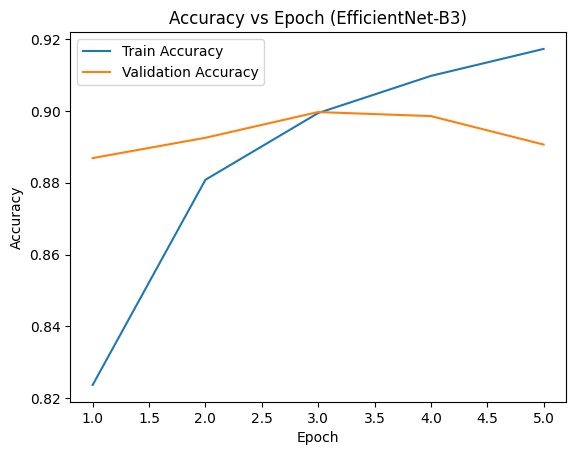

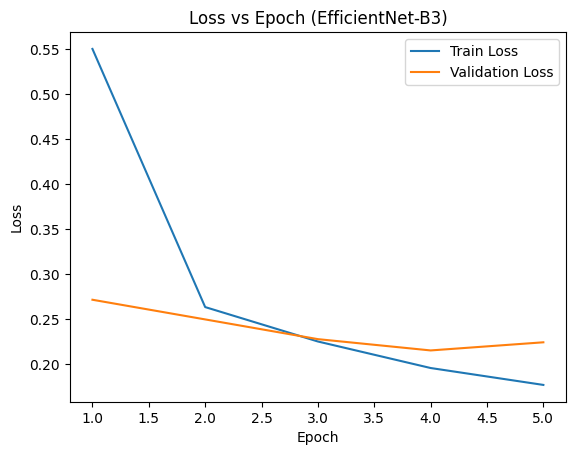

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_acc"]) + 1)

# Accuracy graph
plt.figure()
plt.plot(epochs, history["train_acc"], label="Train Accuracy")
plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch (EfficientNet-B3)")
plt.legend()
plt.show()

# Loss graph
plt.figure()
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch (EfficientNet-B3)")
plt.legend()
plt.show()


In [ ]:
y_true = []
y_pred = []
y_prob = []

model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs[:, 1].cpu().numpy())  # probability of attack


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["bonafide", "attack"]))


Confusion Matrix:
 [[ 934  182]
 [ 126 1411]]

Classification Report:
              precision    recall  f1-score   support

    bonafide       0.88      0.84      0.86      1116
      attack       0.89      0.92      0.90      1537

    accuracy                           0.88      2653
   macro avg       0.88      0.88      0.88      2653
weighted avg       0.88      0.88      0.88      2653



AUC: 0.9649526144819658


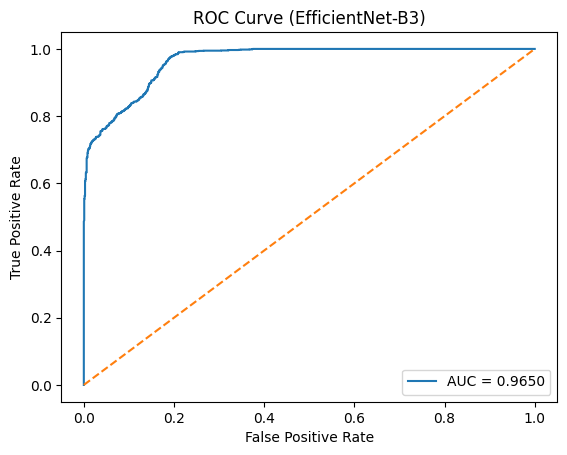

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_prob, pos_label=1)
roc_auc = auc(fpr, tpr)
print("AUC:", roc_auc)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (EfficientNet-B3)")
plt.legend()
plt.show()


In [ ]:
import cv2
import torch
import numpy as np

def predict_image(image_path):
    # read image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # apply same preprocessing as validation set
    processed = val_tf(image=img)["image"]
    processed = processed.unsqueeze(0).to(device)

    # inference
    model.eval()
    with torch.no_grad():
        outputs = model(processed)
        probs = torch.softmax(outputs, dim=1)[0]
        pred_class = torch.argmax(probs).item()

    label = "attack" if pred_class == 1 else "bonafide"
    confidence = float(probs[pred_class])

    return label, confidence


In [ ]:
from google.colab import files
uploaded = files.upload()

for filename in uploaded.keys():
    print("Testing:", filename)
    label, conf = predict_image(filename)
    print(f"Result: {label}  | Confidence: {conf:.4f}")


Saving morphed_image_1.png to morphed_image_1 (1).png
Testing: morphed_image_1 (1).png


NameError: name 'model' is not defined

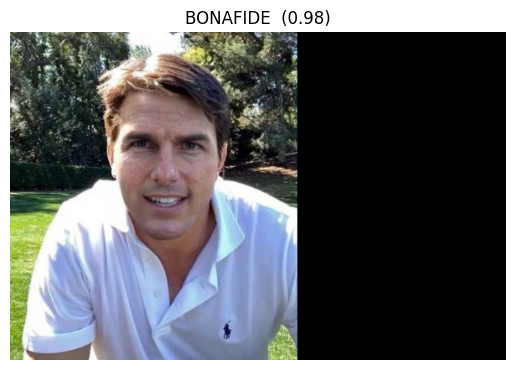

In [ ]:
import matplotlib.pyplot as plt

for filename in uploaded.keys():
    img = cv2.cvtColor(cv2.imread(filename), cv2.COLOR_BGR2RGB)
    label, conf = predict_image(filename)

    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{label.upper()}  ({conf:.2f})")
    plt.show()


In [ ]:
def predict_ensemble(image_path):
    label1, conf1 = predict_vit(image_path)        # Model-1
    label2, conf2 = predict_efficientnet(image_path)  # Model-2

    if label1 == label2:
        return label1, (conf1 + conf2) / 2
    else:
        return "attack", max(conf1, conf2)   # if disagreement, flag risky


In [ ]:
save_path = "/content/drive/MyDrive/morph_project/efficientnet_b3_casia.pth"
torch.save(model.state_dict(), save_path)
print("✅ Model-2 saved permanently at:", save_path)


✅ Model-2 saved permanently at: /content/drive/MyDrive/morph_project/efficientnet_b3_casia.pth


In [ ]:
# ✅ 1. IMPORTS
import torch, timm, cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2
from google.colab import files
import matplotlib.pyplot as plt

# ✅ 2. DEVICE SETUP
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Device:", device)

# ✅ 3. LOAD TRANSFORMS
val_tf = A.Compose([
    A.Resize(224, 224),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    ),
    ToTensorV2()
])

# ✅ 4. LOAD MODEL FROM GOOGLE DRIVE
model = timm.create_model("tf_efficientnet_b3_ns", pretrained=False, num_classes=2)
model_path = "/content/drive/MyDrive/morph_project/efficientnet_b3_casia.pth"

state = torch.load(model_path, map_location=device)
model.load_state_dict(state)
model.to(device)
model.eval()

print("✅ EfficientNet-B3 Loaded Successfully!")

# ✅ 5. PREDICTION FUNCTION WITH VISUAL OUTPUT
def predict_and_show(image_path):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    processed = val_tf(image=img_rgb)["image"].unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(processed)
        probs = torch.softmax(outputs, dim=1)[0]
        pred = torch.argmax(probs).item()

    label = "attack" if pred == 1 else "bonafide"
    confidence = float(probs[pred])

    # show image
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(f"{label.upper()}  |  Confidence: {confidence:.4f}")
    plt.show()

    print(f"✅ Prediction: {label} | Confidence: {confidence:.4f}")


✅ Device: cpu
✅ EfficientNet-B3 Loaded Successfully!


Saving morphed_image_1.png to morphed_image_1 (3).png
Testing: morphed_image_1 (3).png


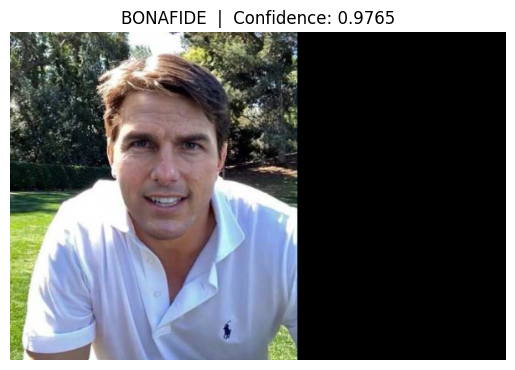

✅ Prediction: bonafide | Confidence: 0.9765


In [ ]:
uploaded = files.upload()

for filename in uploaded.keys():
    print("Testing:", filename)
    predict_and_show(filename)
